# Customer Churn Prediction & Retention Analytics

## 1. Dependencies

In [4]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & modeling
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
    )
 # Model persistence
import pickle

                                        # Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# Reproducibility
RANDOM_STATE = 42

## 2. Data Loading & Initial Inspection

### 2.1 Load Dataset

In [5]:
# Load dataset
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f"Dataset shape: {df.shape}")

Dataset shape: (7043, 21)


In [6]:
df.shape

(7043, 21)

### 2.2 Initial Data Inspection

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


In [8]:
pd.set_option("display.max_columns",None)

In [9]:
df.head(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Data Cleaning

### 3.1 Identify and Handle Invalid TotalCharges Values

In [11]:
# Check values in TotalCharges that cannot be converted to numeric
total_charges_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Values that cannot be converted to numeric:")
print(df.loc[total_charges_numeric.isna(), ["customerID", "tenure", "TotalCharges"]])

print(f"\nNumber of invalid TotalCharges values: {total_charges_numeric.isna().sum()}")

Values that cannot be converted to numeric:
      customerID  tenure TotalCharges
488   4472-LVYGI       0             
753   3115-CZMZD       0             
936   5709-LVOEQ       0             
1082  4367-NUYAO       0             
1340  1371-DWPAZ       0             
3331  7644-OMVMY       0             
3826  3213-VVOLG       0             
4380  2520-SGTTA       0             
5218  2923-ARZLG       0             
6670  4075-WKNIU       0             
6754  2775-SEFEE       0             

Number of invalid TotalCharges values: 11


In [12]:
# Convert TotalCharges to numeric
# Blank values become NaN, then are set to 0 for customers with tenure = 0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Verify the conversion
print("TotalCharges dtype:", df["TotalCharges"].dtype)
print("Missing TotalCharges:", df["TotalCharges"].isna().sum())

TotalCharges dtype: float64
Missing TotalCharges: 0



### 3.2 Verify Missing Values

In [14]:
df.isnull().sum().sort_values(ascending=False)

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### 3.3 Check Categorical Values

In [15]:
for column in df.select_dtypes(include="object").columns:
      print(f"\n{column}:")
      print(df[column].unique())


customerID:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender:
['Female' 'Male']

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn:
['No' 'Yes']


## 4. Data Quality Checks

### 4.1 Duplicate Records

In [13]:
df["customerID"].duplicated().sum()

np.int64(0)

### 4.2 Final Data Quality Check

In [50]:
print("Final Data Types:")
print(df.dtypes)

print("\nFinal Missing Values:")
print(df.isnull().sum())

Final Data Types:
customerID            object
gender                object
SeniorCitizen          int64
Partner               object
Dependents            object
tenure                 int64
PhoneService          object
MultipleLines         object
InternetService       object
OnlineSecurity        object
OnlineBackup          object
DeviceProtection      object
TechSupport           object
StreamingTV           object
StreamingMovies       object
Contract              object
PaperlessBilling      object
PaymentMethod         object
MonthlyCharges       float64
TotalCharges         float64
Churn                 object
TenureGroup         category
dtype: object

Final Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0

## 5. Exploratory Data Analysis

The objective of this section is to understand customer churn patterns across demographic, service, contractual, tenure, and billing characteristics. These insights will guide feature engineering and provide business context for the predictive modeling stage.


### 5.1 Overall Churn Distribution

The overall churn rate establishes the baseline level of customer attrition and helps assess the class imbalance that the predictive model will need to address.

In [16]:
churn_counts = df["Churn"].value_counts()
churn_percent = df["Churn"].value_counts(normalize=True) * 100

print("Customer Count:")
print(churn_counts)

print("\nCustomer Percentage:")
print(churn_percent.round(2))

Customer Count:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Customer Percentage:
Churn
No    73.460
Yes   26.540
Name: proportion, dtype: float64


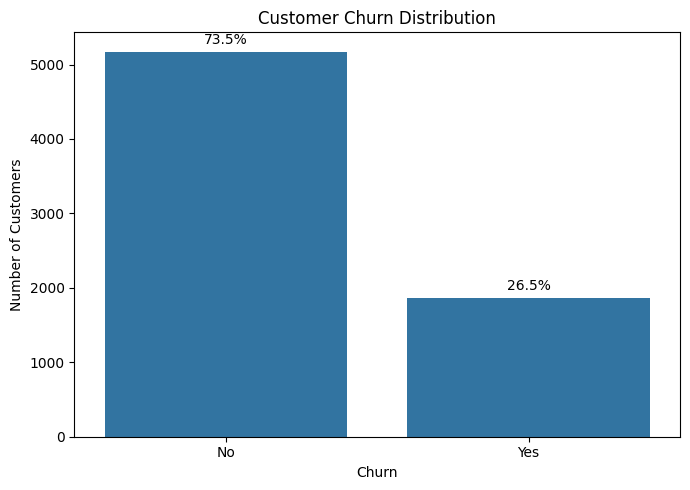

In [17]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
data=df,
x="Churn",
order=["No", "Yes"]
            )

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

# Add percentage labels
total = len(df)

for container in ax.containers:
  labels = [
  f"{(bar.get_height() / total) * 100:.1f}%"
  for bar in container
  ]
  ax.bar_label(container, labels=labels, padding=3)

plt.tight_layout()
plt.show()

**Business Insight:**  
Approximately 26.5% of customers in the dataset have churned, indicating a substantial customer-retention challenge. The imbalance also means that model performance should not be evaluated using accuracy alone, as a model predicting "No Churn" for every customer would already achieve approximately 73.5% accuracy.

### 5.2 Churn by Contract Type

Contract structure can influence customer retention because customers with longer-term commitments may have lower switching flexibility than month-to-month customers. We compare churn rates across contract types to identify potential retention patterns.

In [18]:
contract_churn = (
df.groupby("Contract")["Churn"]
.apply(lambda x: (x == "Yes").mean() * 100)
.sort_values(ascending=False)
)

print("Churn Rate by Contract Type:")
print(contract_churn.round(2))


Churn Rate by Contract Type:
Contract
Month-to-month   42.710
One year         11.270
Two year          2.830
Name: Churn, dtype: float64


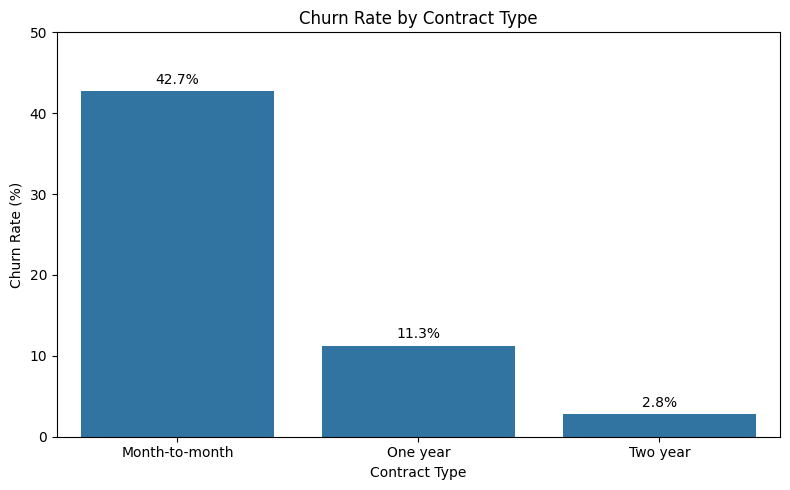

In [19]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=contract_churn.index,
        y=contract_churn.values
        )

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)

for container in ax.containers:
      ax.bar_label(
      container,
      fmt="%.1f%%",
      padding=3
                                        )

plt.tight_layout()
plt.show()

**Business Insight:**  
Month-to-month customers have a substantially higher historical churn rate (42.71%) compared with one-year (11.27%) and two-year (2.83%) customers. This indicates a strong association between contract type and churn and suggests that month-to-month customers may warrant greater attention in retention strategies. However, this analysis is descriptive and does not establish that contract duration itself causes lower churn.

### 5.3 Churn by Customer Tenure

Customer tenure represents the length of the customer relationship with the company. Analyzing churn across tenure groups can help identify periods in the customer lifecycle where retention risk may be higher.

In [20]:
tenure_bins = [0, 6, 12, 24, 48, 72]

tenure_labels = [
"0–6 months",
"7–12 months",
"13–24 months",
"25–48 months",
"49–72 months"
]

df["TenureGroup"] = pd.cut(
df["tenure"],
bins=tenure_bins,
labels=tenure_labels,
include_lowest=True
)

In [21]:
tenure_churn = (
      df.groupby("TenureGroup", observed=True)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
          )

print("Churn Rate by Tenure Group:")
print(tenure_churn.round(2))


Churn Rate by Tenure Group:
TenureGroup
0–6 months     52.940
7–12 months    35.890
13–24 months   28.710
25–48 months   20.390
49–72 months    9.510
Name: Churn, dtype: float64


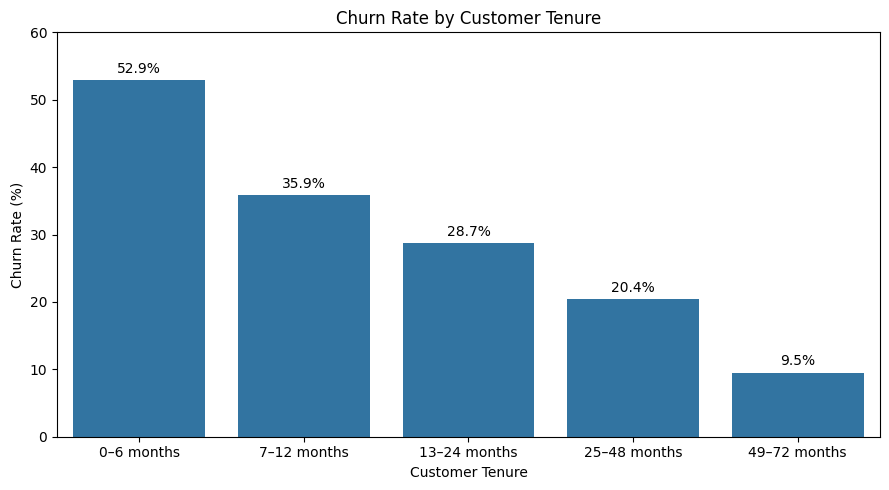

In [22]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=tenure_churn.index,
        y=tenure_churn.values
        )

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 60)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
             )
plt.tight_layout()
plt.show()

**Business Insight:**  
Churn is highest among customers with shorter tenure, reaching 52.94% for customers in their first 6 months compared with 9.51% for customers with 49–72 months of tenure. This indicates that the early customer lifecycle is a particularly high-risk period and may warrant stronger onboarding, early engagement, and proactive retention efforts. However, this descriptive analysis identifies an association rather than a causal relationship.

 ### 5.4 Monthly Charges by Churn Status

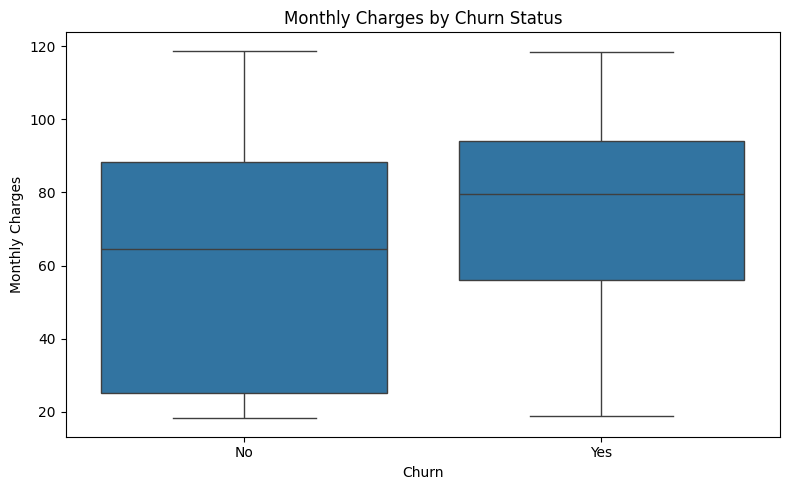

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
data=df,
x="Churn",
y="MonthlyCharges",
order=["No", "Yes"]
                )

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

In [24]:
monthly_charge_summary = (
 df.groupby("Churn")["MonthlyCharges"]
.agg(["mean", "median"])
.round(2)
               )

print("Monthly Charges by Churn Status:")
print(monthly_charge_summary)


Monthly Charges by Churn Status:
        mean  median
Churn               
No    61.270  64.430
Yes   74.440  79.650


**Business Insight:**  
Customers who churned had higher average and median monthly charges than customers who remained, with median monthly charges of 79.65 compared with 64.43 for retained customers. This suggests an association between higher recurring charges and churn risk, although the substantial overlap between the two distributions indicates that monthly charges alone are not sufficient to explain customer churn.

### 5.5 Churn by Internet Service

Internet service is an important part of the customer's service experience. Comparing churn rates across service types helps identify whether certain customer segments have higher observed churn.

In [25]:
internet_churn = (
df.groupby("InternetService")["Churn"]
.apply(lambda x: (x == "Yes").mean() * 100)
.sort_values(ascending=False)
)

print("Churn Rate by Internet Service:")
print(internet_churn.round(2))


Churn Rate by Internet Service:
InternetService
Fiber optic   41.890
DSL           18.960
No             7.400
Name: Churn, dtype: float64


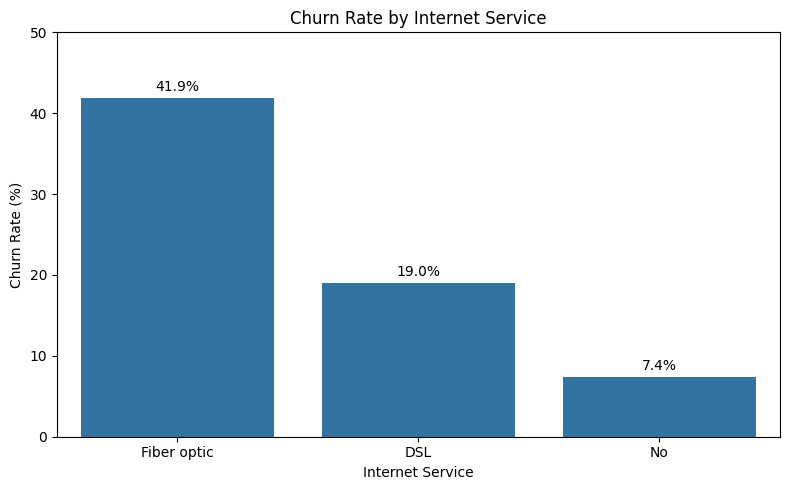

In [26]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=internet_churn.index,
        y=internet_churn.values
        )

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)

for container in ax.containers:
   ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

**Business Insight:**  
Fiber optic customers have the highest observed churn rate at 41.89%, compared with 18.96% for DSL and 7.40% for customers without internet service. This identifies Fiber optic customers as a segment that may warrant further investigation. However, the relationship may be influenced by other customer characteristics such as tenure, contract type, and monthly charges, which will be considered in the predictive model.

### 5.6 Churn by Payment Method

Payment method can influence the customer's billing experience and may be associated with retention behavior. We compare churn rates across payment methods to identify segments with unusually high observed churn.

In [27]:
payment_churn = (
      df.groupby("PaymentMethod")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
             )

print("Churn Rate by Payment Method:")
print(payment_churn.round(2))


Churn Rate by Payment Method:
PaymentMethod
Electronic check            45.290
Mailed check                19.110
Bank transfer (automatic)   16.710
Credit card (automatic)     15.240
Name: Churn, dtype: float64


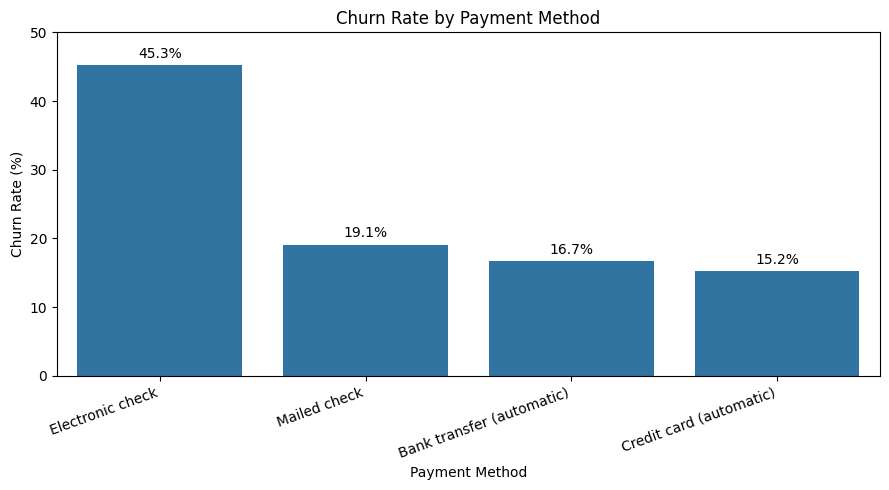

In [28]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=payment_churn.index,
        y=payment_churn.values
        )

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)
plt.xticks(rotation=20, ha="right")

for container in ax.containers:
   ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

**Business Insight:**  
Electronic check customers have the highest observed churn rate at 45.29%, substantially above mailed check (19.11%), automatic bank transfer (16.71%), and automatic credit card payments (15.24%). This identifies electronic-check customers as a high-risk segment that may warrant further investigation into billing experience and payment-related friction. The analysis shows an association and does not establish causality.

## 6. Data Preparation for Modeling

The target variable is separated from the customer features before model development. Customer identifiers and exploratory-only variables are excluded from the predictive feature set because they do not represent meaningful customer behavior.

### 6.1 Separating Features and Target

In [29]:
# Create target variable
y = df["Churn"].map({"No": 0, "Yes": 1})

# Create feature dataset
X = df.drop(
    columns=["Churn", "customerID", "TenureGroup"]
    )

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7043, 19)
Target shape: (7043,)


### 6.2 Train-Test Split

The dataset is divided into training and testing subsets using an 80:20 split. Stratified sampling is used to preserve the original churn proportion in both subsets, ensuring a representative evaluation set.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,
random_state=RANDOM_STATE,stratify=y)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining churn rate:", f"{y_train.mean():.2%}")
print("Testing churn rate:", f"{y_test.mean():.2%}")


Training set: (5634, 19)
Testing set: (1409, 19)

Training churn rate: 26.54%
Testing churn rate: 26.54%


### 6.3 Identifying Numerical and Categorical Features

The predictors contain both numerical and categorical variables. Numerical variables can be passed directly to the model after appropriate scaling where required, while categorical variables need to be converted into numerical representations.

In [31]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### 6.4 Feature Preprocessing

Numerical and categorical variables require different preprocessing approaches. Numerical variables are standardized for models that are sensitive to feature scale, while categorical variables are converted into binary indicator variables using one-hot encoding.

In [32]:
preprocessor = ColumnTransformer(
      transformers=[
   (
      "num",
       StandardScaler(),
      numeric_features
     ),
   (
    "cat",
     OneHotEncoder(handle_unknown="ignore"),
     categorical_features
)
]
)


In [33]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.850,No,0–6 months
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.500,No,25–48 months
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.150,Yes,0–6 months
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.750,No,25–48 months
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.650,Yes,0–6 months


### 6.5 Baseline Model — Logistic Regression

Logistic Regression is used as an interpretable baseline for predicting customer churn. Its performance will provide a reference point for evaluating more complex models and class-balancing approaches.

In [34]:
logistic_pipeline = Pipeline(
      steps=[
           ("preprocessor", preprocessor),
            ("model", LogisticRegression(
                  max_iter=1000,
                  random_state=RANDOM_STATE
                                                      ))
                                                          ]
                                                          )


### 6.6 Training the Baseline Model

The Logistic Regression pipeline is fitted using only the training dataset. Preprocessing is learned within the pipeline to ensure that information from the test set is not used during model training.

In [35]:
# Train the baseline model
logistic_pipeline.fit(X_train, y_train)

print("Baseline Logistic Regression model trained successfully.")

Baseline Logistic Regression model trained successfully.


### 6.7 Generating Predictions

The trained model is used to generate both binary churn predictions and churn probabilities for the unseen test dataset. Probabilities will later support customer risk prioritization.

In [36]:
# Predict churn class
y_pred = logistic_pipeline.predict(X_test)

# Predict probability of churn
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

print("First 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 churn probabilities:")
print(y_prob[:10])

First 10 predictions:
[0 1 0 0 0 1 0 0 0 0]

First 10 churn probabilities:
[0.04591993 0.68371345 0.05893985 0.40183529 0.02142426 0.60297803
 0.44762898 0.13033554 0.00280355 0.39473874]


### 6.8 Baseline Model Evaluation

The baseline model is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. Because the business objective is to identify customers at risk of churn, recall and F1-score are particularly important alongside overall discrimination measured by ROC-AUC.

In [37]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-Score : {f1:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")

Accuracy : 0.806
Precision: 0.657
Recall   : 0.559
F1-Score : 0.604
ROC-AUC  : 0.842


### 6.9 Confusion Matrix

The confusion matrix provides a detailed view of the baseline model's classification errors, with particular attention to false negatives because these represent customers who churned but were not identified by the model.

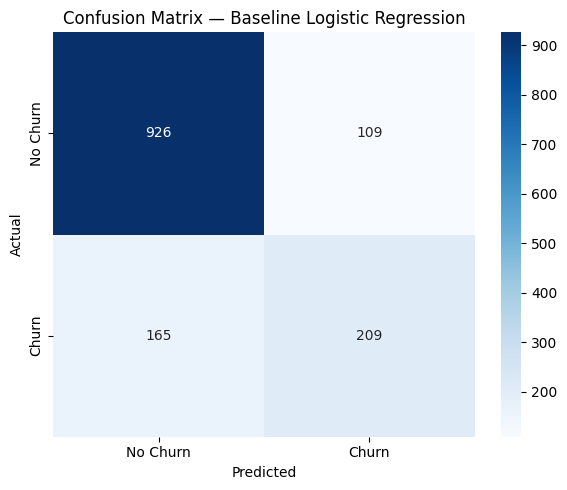

In [38]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
                        )

plt.title("Confusion Matrix — Baseline Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

### 6.10 Random Forest Model

In [39]:
random_forest_pipeline = Pipeline(
      steps=[
              ("preprocessor", preprocessor),
               ("model", RandomForestClassifier(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1
                         ))
                  ]
          )


### 6.11 Training the Random Forest Model

The Random Forest model is trained on the same training dataset used for the baseline model, allowing its performance to be compared fairly with Logistic Regression.

In [40]:
# Train Random Forest
random_forest_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### 6.12 Random Forest Predictions

The trained Random Forest is used to generate churn classifications and churn probabilities on the unseen test dataset.

In [41]:
# Predict churn class
rf_pred = random_forest_pipeline.predict(X_test)

# Predict probability of churn
rf_prob = random_forest_pipeline.predict_proba(X_test)[:, 1]

print("First 10 predictions:")
print(rf_pred[:10])

print("\nFirst 10 churn probabilities:")
print(rf_prob[:10])

First 10 predictions:
[0 1 0 0 0 0 0 0 0 0]

First 10 churn probabilities:
[0.         0.71666667 0.05       0.30333333 0.01333333 0.34333333
 0.36       0.06333333 0.00666667 0.45666667]


### 6.13 Random Forest Evaluation

The Random Forest model is evaluated using the same metrics as the Logistic Regression baseline to determine whether the nonlinear ensemble provides better churn prediction performance.

In [42]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print(f"Accuracy : {rf_accuracy:.3f}")
print(f"Precision: {rf_precision:.3f}")
print(f"Recall   : {rf_recall:.3f}")
print(f"F1-Score : {rf_f1:.3f}")
print(f"ROC-AUC  : {rf_roc_auc:.3f}")

Accuracy : 0.782
Precision: 0.614
Recall   : 0.481
F1-Score : 0.540
ROC-AUC  : 0.819


**Model Comparison Insight:**  
The initial Random Forest model underperformed the Logistic Regression baseline across accuracy, precision, recall, F1-score, and ROC-AUC. Logistic Regression achieved the strongest performance so far, with an ROC-AUC of 0.842 compared with 0.819 for Random Forest. This indicates that the more complex tree-based model did not automatically provide better predictive performance.

### 6.14 XGBoost Model

XGBoost is evaluated as a gradient-boosting model to determine whether sequentially learning from previous model errors can improve churn prediction compared with Logistic Regression and Random Forest.

In [43]:
xgb_pipeline = Pipeline(
      steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
        n_estimators=300,
         max_depth=4,
          learning_rate=0.05,
           subsample=0.8,
                                                                                            colsample_bytree=0.8,
                                                                                           random_state=RANDOM_STATE,
                                                                                              eval_metric="logloss"
                                                                                               ))
                                                                                        ]
                                                                                            )


### 6.15 Training the XGBoost Model

The XGBoost model is trained using the same training data and preprocessing pipeline as the previous models, allowing a consistent comparison of predictive performance.

In [44]:
# Train XGBoost
xgb_pipeline.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


### 6.16 XGBoost Predictions

The trained XGBoost model is used to generate churn classifications and churn probabilities on the unseen test dataset.

In [45]:
# Predict churn class
xgb_pred = xgb_pipeline.predict(X_test)

# Predict probability of churn
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

print("First 10 predictions:")
print(xgb_pred[:10])

print("\nFirst 10 churn probabilities:")
print(xgb_prob[:10])

First 10 predictions:
[0 1 0 0 0 1 0 0 0 0]

First 10 churn probabilities:
[0.01143758 0.89285284 0.06820881 0.3723952  0.00636157 0.6694355
 0.47899523 0.12049049 0.01932134 0.4169265 ]


### 6.17 XGBoost Evaluation

The XGBoost model is evaluated using the same metrics as the Logistic Regression and Random Forest models to enable a consistent comparison.

In [46]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_prob)

print(f"Accuracy : {xgb_accuracy:.3f}")
print(f"Precision: {xgb_precision:.3f}")
print(f"Recall   : {xgb_recall:.3f}")
print(f"F1-Score : {xgb_f1:.3f}")
print(f"ROC-AUC  : {xgb_roc_auc:.3f}")

Accuracy : 0.805
Precision: 0.668
Recall   : 0.527
F1-Score : 0.589
ROC-AUC  : 0.841


### 6.18 Model Comparison

Three classification models were evaluated using the same train-test split and preprocessing pipeline. Logistic Regression achieved the strongest overall performance, with an ROC-AUC of 0.842, recall of 55.9%, and F1-score of 60.4%. XGBoost achieved slightly higher precision (66.8%) but lower recall and F1-score, while Random Forest underperformed both models. Given the retention objective, Logistic Regression is selected as the current preferred model because of its stronger ability to identify actual churners while maintaining good overall discrimination.

## 7. Business-Oriented Threshold Optimization

The default 0.50 classification threshold is evaluated against alternative thresholds to understand the trade-off between identifying more potential churners and generating additional false-positive retention alerts.

### 7.1 Evaluating Classification Thresholds

In [47]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

for threshold in thresholds:
    threshold_pred = (y_prob >= threshold).astype(int)

    print(
      f"Threshold: {threshold:.2f} | "
      f"Precision: {precision_score(y_test, threshold_pred):.3f} | "
      f"Recall: {recall_score(y_test, threshold_pred):.3f} | "
      f"F1: {f1_score(y_test, threshold_pred):.3f}"
)

Threshold: 0.30 | Precision: 0.519 | Recall: 0.754 | F1: 0.615
Threshold: 0.40 | Precision: 0.568 | Recall: 0.668 | F1: 0.614
Threshold: 0.50 | Precision: 0.657 | Recall: 0.559 | F1: 0.604
Threshold: 0.60 | Precision: 0.718 | Recall: 0.401 | F1: 0.515
Threshold: 0.70 | Precision: 0.742 | Recall: 0.184 | F1: 0.296


**Threshold Selection Insight:**  
The default 0.50 threshold produced 55.9% recall, while reducing the threshold to 0.30 increased recall to 75.4% and slightly improved F1-score from 60.4% to 61.5%. Given the retention objective, the 0.30 threshold is selected as the current business-oriented threshold because it prioritizes identifying a larger proportion of potential churners. This comes with lower precision (51.9%), meaning more customers may be flagged for retention efforts unnecessarily. In a production setting, the final threshold should be determined using the relative costs of missed churners and retention interventions.

## 8. Model Explainability

The selected Logistic Regression model provides interpretable coefficients that can be used to identify features associated with higher or lower predicted churn. This helps translate model outputs into business-relevant insights.

### 8.1 Logistic Regression Feature Importance

In [48]:
# Get feature names after preprocessing
feature_names = logistic_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = logistic_pipeline.named_steps["model"].coef_[0]

# Create a DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
        "Coefficient": coefficients
        })

        # Sort by coefficient
feature_importance = feature_importance.sort_values(
            "Coefficient",
                ascending=False
                )

print("Top 10 features associated with higher predicted churn:")
print(feature_importance.head(10))

print("\nTop 10 features associated with lower predicted churn:")
print(feature_importance.tail(10))

Top 10 features associated with higher predicted churn:
                                Feature  Coefficient
16     cat__InternetService_Fiber optic        0.634
36         cat__Contract_Month-to-month        0.583
3                     num__TotalCharges        0.536
35             cat__StreamingMovies_Yes        0.201
32                 cat__StreamingTV_Yes        0.200
43  cat__PaymentMethod_Electronic check        0.198
18               cat__OnlineSecurity_No        0.156
27                  cat__TechSupport_No        0.132
14               cat__MultipleLines_Yes        0.105
0                    num__SeniorCitizen        0.053

Top 10 features associated with lower predicted churn:
                                      Feature  Coefficient
19    cat__OnlineSecurity_No internet service       -0.300
17                    cat__InternetService_No       -0.300
31       cat__StreamingTV_No internet service       -0.300
25  cat__DeviceProtection_No internet service       -0.300
22      ca

### 8.2 Business Interpretation of Model Coefficients

The Logistic Regression coefficients broadly support the patterns identified during EDA. Fiber optic service and month-to-month contracts show positive associations with predicted churn, while tenure and two-year contracts show strong negative associations. This consistency suggests that customer lifecycle and contract structure are important factors in churn prediction. The coefficients represent model associations rather than causal effects.

## 9. Customer Risk Segmentation & Retention Strategy

The selected Logistic Regression model produces a churn probability for each customer. These probabilities are converted into simple risk segments to support prioritization of retention efforts.

### 9.1 Creating Customer Risk Segments

In [49]:
risk_segment = pd.cut(
      y_prob,
      bins=[-0.01, 0.30, 0.60, 1.00],
      labels=["Low Risk", "Medium Risk", "High Risk"]
              )

risk_summary = risk_segment.value_counts().sort_index()

print("Customer Risk Segmentation:")
print(risk_summary)


Customer Risk Segmentation:
Low Risk       866
Medium Risk    334
High Risk      209
Name: count, dtype: int64


**Business Insight:**  
The model classified 209 of the 1,409 test customers (14.8%) as high risk, 334 (23.7%) as medium risk, and 866 (61.5%) as low risk. This segmentation can help a retention team prioritize high-risk customers for proactive intervention while using less intensive engagement for lower-risk segments. These segments are based on model predictions and should be validated against actual retention outcomes before deployment.

### 9.2 Recommended Retention Actions

Based on the exploratory analysis and model results, the following actions could be considered:

1. **Prioritize early-tenure customers:** Customers in their first 6–12 months show substantially higher observed churn, suggesting a need for stronger onboarding and early engagement.

2. **Target month-to-month customers:** Month-to-month customers have substantially higher observed churn than customers on longer contracts. The company could test incentives for suitable customers to move to longer-term plans.

3. **Investigate Fiber optic churn:** Fiber optic customers show considerably higher observed churn than DSL and no-internet customers. Service quality, pricing, and customer experience should be investigated before designing targeted interventions.

4. **Review electronic-check customers:** Electronic-check users have substantially higher observed churn. The company could investigate billing/payment friction and encourage convenient automatic payment options where appropriate.

5. **Prioritize model-identified high-risk customers:** Customers with predicted churn probability of at least 60% can receive the highest-priority retention attention, while customers above the 30% intervention threshold can be considered for broader proactive engagement.